# Notebook 1 — SOLUTION

## Short version

**There are no clusters.** Every neuron is independent noise plus a single
smooth bump, and each neuron's bump peaks at a *randomly chosen, continuous*
time. Peak time is a smooth continuum with no gaps and no modes.

k-means with `k = 3` is *required* to return 3 groups — so it does. It simply
slices the continuous peak-time axis into three contiguous bins and calls them
"early", "middle", and "late". The mean-trace plot then hides the continuous
spread *within* each bin, making the arbitrary slices look like real classes.

"But silhouette analysis *chose* k = 3!" — it did, and that is exactly why the
result is so seductive. As we show in Evidence 4, a silhouette peak at k = 3
appears even in data we *know* has no clusters, and the peak value here is low
enough to indicate no real structure. Model selection tells you the best k
*given that you are going to cluster*; it does not tell you whether you should
be clustering at all.

Below we show four independent lines of evidence.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Plotting style ---
plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

rng = np.random.default_rng(0)  # for cosmetic row shuffling only

HEAT_CMAP = 'inferno'           # perceptually-uniform colormap for heatmaps

def cluster_palette(n):
    """n distinct qualitative colors, one per cluster."""
    return plt.cm.tab10(np.arange(n) % 10)

def cluster_label(c, k):
    """Human-readable cluster name. For k=3 use early/middle/late."""
    if k == 3:
        return f'cluster {c} ({["early", "middle", "late"][c]})'
    return f'cluster {c}'


In [2]:
# Load the dataset: a (neurons x time) matrix of activity.
d = np.load('data/activity.npz')
activity = d['activity']      # shape (n_neurons, n_time)
time = d['time']              # seconds
n_neurons, n_time = activity.shape
print(f'{n_neurons} neurons x {n_time} time bins '
      f'({time[0]:.2f}-{time[-1]:.2f} s)')


300 neurons x 100 time bins (0.00-4.95 s)


In [3]:
# Reproduce the k=3 clustering from the student notebook.
from scipy.ndimage import gaussian_filter1d

k = 3
labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(activity)
# Relabel clusters early -> middle -> late by their mean-trace peak (cosmetic).
peak_of_mean = np.array([activity[labels == c].mean(0).argmax() for c in range(k)])
order = np.argsort(peak_of_mean)
relabel = np.zeros(k, dtype=int); relabel[order] = np.arange(k)
labels = relabel[labels]
colors = cluster_palette(k)


## Evidence 1 — Estimate each neuron's peak time from the data

We don't need the generative parameters: we can estimate each neuron's peak
time directly by lightly smoothing its trace and taking the argmax. If there
were three response classes, the distribution of peak times would be
**trimodal**. It is not — it is flat (uniform) and continuous.


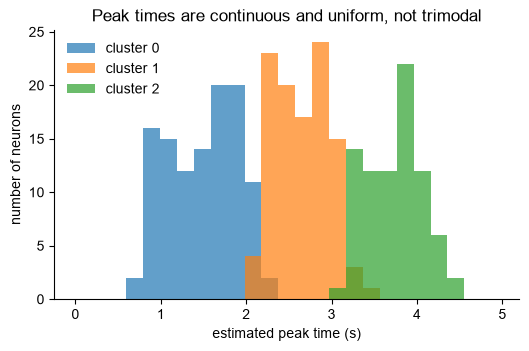

The clusters are simply contiguous slices of the peak-time axis:
  cluster 0: peak time in [0.70, 2.35] s
  cluster 1: peak time in [2.15, 3.40] s
  cluster 2: peak time in [3.15, 4.50] s


In [4]:
# Lightly smooth each neuron's trace in time, then take the time of its maximum
# as an estimate of that neuron's "peak time" (argmax over the time axis).
smoothed = gaussian_filter1d(activity, sigma=2.0, axis=1)
peak_time_est = time[smoothed.argmax(1)]   # peak time (in s) for each neuron

fig, ax = plt.subplots(figsize=(6, 3.5))
for c in range(k):
    ax.hist(peak_time_est[labels == c], bins=np.linspace(time[0], time[-1], 26),
            color=colors[c], alpha=0.7, label=f'cluster {c}')
ax.set_xlabel('estimated peak time (s)')
ax.set_ylabel('number of neurons')
ax.set_title('Peak times are continuous and uniform, not trimodal')
ax.legend(frameon=False)
plt.show()

print('The clusters are simply contiguous slices of the peak-time axis:')
for c in range(k):
    pt = peak_time_est[labels == c]
    print(f'  cluster {c}: peak time in [{pt.min():.2f}, {pt.max():.2f}] s')


The cluster ranges are **contiguous and non-overlapping** — the boundaries are
just cut points on a single continuous variable. That is what k-means does to a
continuum: it partitions it into k contiguous cells (a 1-D Voronoi
tessellation), regardless of whether any gaps exist.


## Evidence 2 — Sort *all* neurons by peak time in one heatmap

The per-cluster heatmaps used arbitrary row order and were split into three
panels, which invites the eye to see three blocks. Put every neuron in one
heatmap, sorted by peak time, and the truth appears: a single smooth diagonal
sweep — a continuum, with no block boundaries.


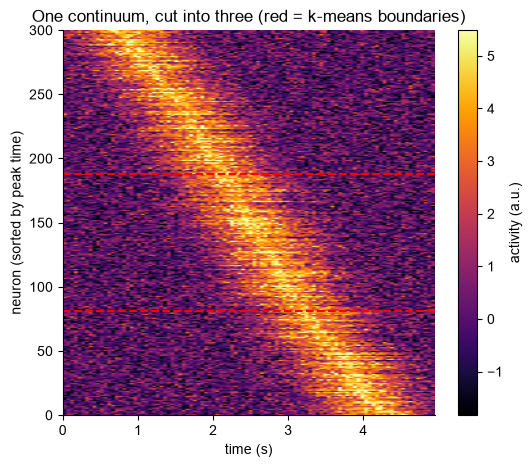

In [5]:
sort_idx = np.argsort(peak_time_est)    # neuron order from earliest to latest peak
vmin = np.percentile(activity, 2)
vmax = np.percentile(activity, 99)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(activity[sort_idx], aspect='auto', cmap=HEAT_CMAP,
               vmin=vmin, vmax=vmax,
               extent=[time[0], time[-1], 0, activity.shape[0]])
# Mark where k-means splits this continuum. Clusters are ordered by peak
# time, so the boundaries sit at the cumulative cluster sizes.
sizes = [int((labels == c).sum()) for c in range(k)]
for b in np.cumsum(sizes)[:-1]:
    ax.axhline(activity.shape[0] - b, color='red', lw=1.5, ls='--')
ax.set_xlabel('time (s)')
ax.set_ylabel('neuron (sorted by peak time)')
ax.set_title('One continuum, cut into three (red = k-means boundaries)')
plt.colorbar(im, ax=ax, label='activity (a.u.)')
plt.show()


## Evidence 3 — PCA shows a continuous arch, not separated blobs

Project the neurons onto their first two principal components (plain SVD). If
there were three clusters, we'd see three separated clouds. Instead the
neurons lie on a smooth 1-D arch: the classic signature of a single latent
parameter (here, peak time) varying continuously. Coloring by k-means label
just paints three adjacent arcs of the *same* arch; coloring by peak time shows
the arch *is* the peak-time axis.


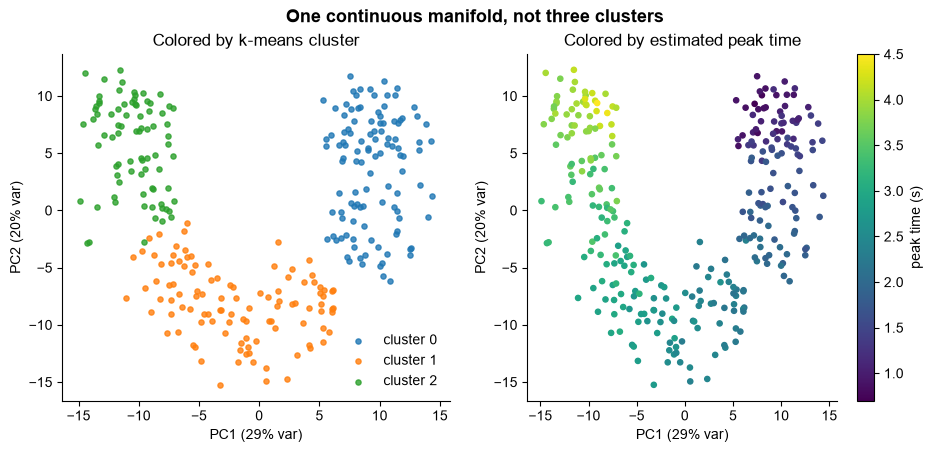

In [6]:
# PCA via SVD (no sklearn needed).
Xc = activity - activity.mean(0)                 # center each time point (column)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
pcs = U * S                                      # each neuron's coordinates in PC space
var_exp = S**2 / np.sum(S**2)                    # fraction of variance per PC

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
for c in range(k):
    m = labels == c
    ax.scatter(pcs[m, 0], pcs[m, 1], s=14, color=colors[c],
               alpha=0.8, label=f'cluster {c}')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.0f}% var)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.0f}% var)')
ax.set_title('Colored by k-means cluster')
ax.legend(frameon=False)

ax = axes[1]
sc = ax.scatter(pcs[:, 0], pcs[:, 1], s=14, c=peak_time_est, cmap='viridis')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.0f}% var)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.0f}% var)')
ax.set_title('Colored by estimated peak time')
plt.colorbar(sc, ax=ax, label='peak time (s)')

fig.suptitle('One continuous manifold, not three clusters',
             fontsize=13, fontweight='bold')
plt.show()


## Evidence 4 — The silhouette "peak" at k = 3 is meaningless

The student notebook justified `k = 3` with silhouette analysis, and indeed the
silhouette score *does* peak at k = 3. Doesn't that prove three clusters exist?
No — for two reasons.

**1. The peak value is low.** As a rough rule of thumb (Kaufman & Rousseeuw), a
silhouette below ~0.25 indicates *no substantial* cluster structure; 0.25-0.5 is
"weak". Our peak sits right around that floor. Silhouette always names a "best"
k, but the *value* tells you how real the structure is — and here it says
"barely any".

**2. The same peak appears in data with no clusters.** This is the decisive
test. We simulate surrogate datasets from a purely *continuous* model — one
smooth bump per neuron at a uniformly random peak time, no groups whatsoever
(exactly the structure Evidence 1-3 established) — and run the identical
silhouette sweep. If a peak at k = 3 were evidence of clusters, these
no-cluster surrogates should not reproduce it. They do, at the same low value.


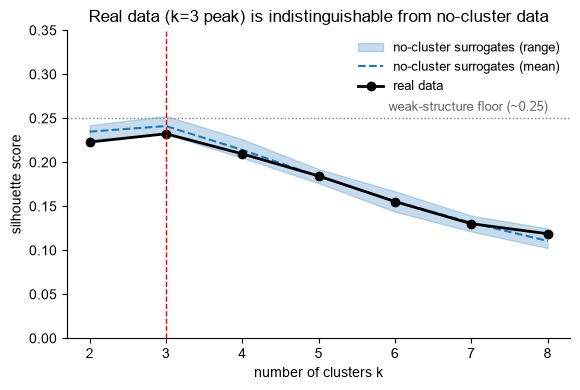

real data:  best k = 3, peak silhouette = 0.232
surrogates: peak silhouette = 0.242 (mean across 12 datasets we KNOW have no clusters)


In [7]:
from sklearn.metrics import silhouette_score

ks = list(range(2, 9))

def silhouette_curve(X):
    return [silhouette_score(X, KMeans(n_clusters=kk, n_init=10,
            random_state=0).fit_predict(X)) for kk in ks]

# --- Real data ---
sil_real = silhouette_curve(activity)

# --- No-cluster surrogates: one smooth bump per neuron at a random time ---
def simulate_continuous(seed, shape=activity.shape):
    n, T = shape
    r = np.random.default_rng(seed)
    peak = r.uniform(0.15 * T, 0.85 * T, size=n)        # continuous, no groups
    t = np.arange(T)[None, :]
    bumps = 4.0 * np.exp(-0.5 * ((t - peak[:, None]) / 9.0) ** 2)
    return r.normal(0, 1.0, size=(n, T)) + r.uniform(0.7, 1.3, size=(n, 1)) * bumps

sil_surr = np.array([silhouette_curve(simulate_continuous(s)) for s in range(12)])

fig, ax = plt.subplots(figsize=(6.5, 4))
# surrogate band (min-max across the no-cluster simulations)
ax.fill_between(ks, sil_surr.min(0), sil_surr.max(0), color='tab:blue',
                alpha=0.25, label='no-cluster surrogates (range)')
ax.plot(ks, sil_surr.mean(0), color='tab:blue', lw=1.5, ls='--',
        label='no-cluster surrogates (mean)')
ax.plot(ks, sil_real, 'o-', color='k', lw=2, label='real data')
ax.axhline(0.25, color='0.5', ls=':', lw=1)
ax.text(8, 0.255, 'weak-structure floor (~0.25)', ha='right', va='bottom',
        color='0.4', fontsize=9)
ax.axvline(3, color='red', ls='--', lw=1)
ax.set_xlabel('number of clusters k')
ax.set_ylabel('silhouette score')
ax.set_title('Real data (k=3 peak) is indistinguishable from no-cluster data')
ax.set_ylim(0, 0.35)
ax.legend(frameon=False, fontsize=9)
plt.show()

print(f'real data:  best k = {ks[int(np.argmax(sil_real))]}, '
      f'peak silhouette = {max(sil_real):.3f}')
print(f'surrogates: peak silhouette = {sil_surr.max(1).mean():.3f} '
      f'(mean across 12 datasets we KNOW have no clusters)')


## Confirmation with the generative ground truth

Since these are synthetic data, we can check directly. The generator drew each
neuron's peak time from a **continuous uniform distribution** and added a single
Gaussian bump — no groups anywhere. The k-means labels line up exactly with
tertiles of the true peak time.


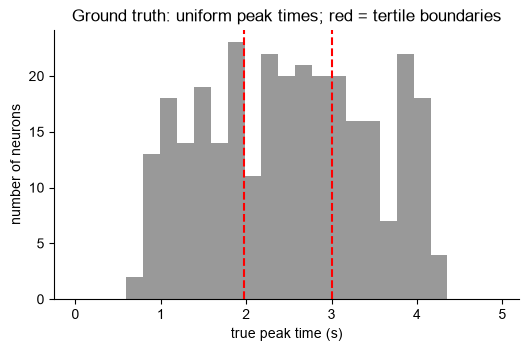

Estimated vs. true peak time correlation: 0.992


In [8]:
gt = np.load('data/ground_truth.npz')
true_peak = gt['peak_times']

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(true_peak, bins=np.linspace(time[0], time[-1], 26), color='0.6')
for q in np.quantile(true_peak, [1/3, 2/3]):
    ax.axvline(q, color='red', ls='--')
ax.set_xlabel('true peak time (s)')
ax.set_ylabel('number of neurons')
ax.set_title('Ground truth: uniform peak times; red = tertile boundaries')
plt.show()

print('Estimated vs. true peak time correlation:',
      round(np.corrcoef(peak_time_est, true_peak)[0, 1], 3))


## The lesson

- **k-means always returns k clusters.** Asking for 3 groups guarantees 3
  groups, whether or not any exist. The output is not evidence that discrete
  classes are present.
- **A continuum will be sliced into contiguous bins.** When a single latent
  variable (here, peak time) varies smoothly, clustering carves it into
  arbitrary "types" whose boundaries are meaningless.
- **Averaging within groups hides the within-group distribution.** The tidy
  mean +/- SEM traces conceal that peak times vary continuously across the
  whole trial; the SEM is small only because n is large, not because the group
  is homogeneous.
- **A "best k" is not evidence of clusters.** Silhouette (or gap statistic,
  BIC, etc.) selects the best k *assuming you cluster at all*. It happily peaks
  on a continuum — the peak here is reproduced by data we know has no groups.
  Always read the *value*, and compare it against a matched no-cluster null.
- **Averaging within groups hides the within-group distribution.** The tidy
  mean +/- SEM traces conceal that peak times vary continuously across the
  whole trial; the SEM is small only because n is large, not because the group
  is homogeneous.

**How to do it right:** before interpreting clusters as types, ask whether a
continuous model explains the data at least as well, compare any cluster-validity
metric against a matched null (not just its own maximum), and visualize the data
in a way that does not presuppose the number of groups.
